In [1]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
plt.style.use('default')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Load data
url = "https://raw.githubusercontent.com/diplomadoequipo908-a11y/Proyecto-modulo-5/main/dataset.csv"
raw = pd.read_csv(url)
raw = raw.drop(columns=['Unnamed: 0'])
# Drop duplicates on track_id keep unique tracks.
df = raw.drop_duplicates(subset='track_id').copy().reset_index(drop=True)
print('Raw data:',raw.shape)
print('Unique tracks data:',df.shape)
df.describe()

Raw data: (114000, 20)
Unique tracks data: (89741, 20)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,33.198438,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,20.580824,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Data Dictionary
| Column | Type | Range | Description |
|---|---|---|---|
| `track_id` | String | — | Unique Spotify URI identifier for the track |
| `artists` | String | — | Performing artist name(s) |
| `album_name` | String | — | Album the track belongs to |
| `track_name` | String | — | Title of the track |
| `popularity` | Integer | 0 – 100 | Spotify popularity score (higher = more popular) |
| `duration_ms` | Integer | 0 – 5.2M | Track duration in milliseconds |
| `explicit` | Boolean | True/False | Whether the track has explicit lyrics |
| `danceability` | Float | 0.0 – 1.0 | How suitable a track is for dancing |
| `energy` | Float | 0.0 – 1.0 | Perceptual measure of intensity and activity |
| `key` | Integer | 0 – 11 | Musical key (0=C, 1=C♯, 2=D … 11=B) |
| `loudness` | Float | -49.5 – 4.5 | Overall loudness in decibels (dB) |
| `mode` | Integer | 0 or 1 | Modality — 1 = Major, 0 = Minor |
| `speechiness` | Float | 0.0 – 1.0 | Presence of spoken words in the track |
| `acousticness` | Float | 0.0 – 1.0 | Confidence the track is acoustic |
| `instrumentalness` | Float | 0.0 – 1.0 | Predicts whether a track has no vocals |
| `liveness` | Float | 0.0 – 1.0 | Detects presence of a live audience |
| `valence` | Float | 0.0 – 1.0 | Musical positiveness conveyed by the track |
| `tempo` | Float | 0 – 243 | Estimated tempo in beats per minute (BPM) |
| `time_signature` | Integer | 0 – 5 | Estimated time signature of the track |
| `track_genre` | String | 114 classes | Genre label assigned to the track |

#### For scale purposes, we will use a log transform for duration_ms since most of the features are scales between (0,1)

In [3]:
df['duration_ms'] = np.log1p(
    df['duration_ms']
)

## Null values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
loudness            0
mode                0
key                 0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64


In [5]:
# fill null values
for col in ['track_name', 'album_name', 'artists']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


In [6]:
df.columns.tolist()

['track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

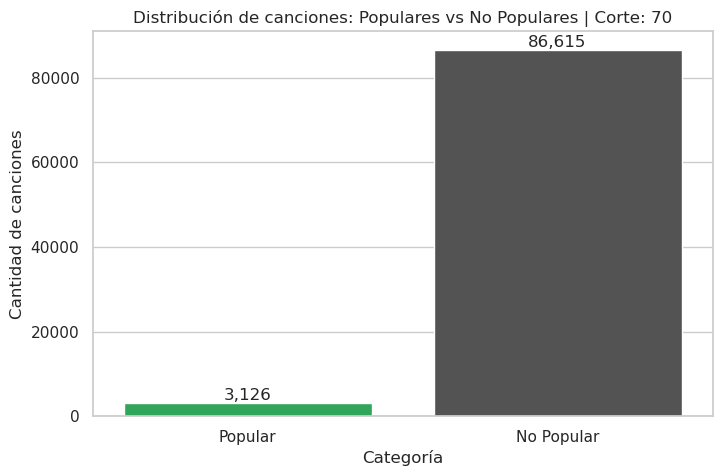

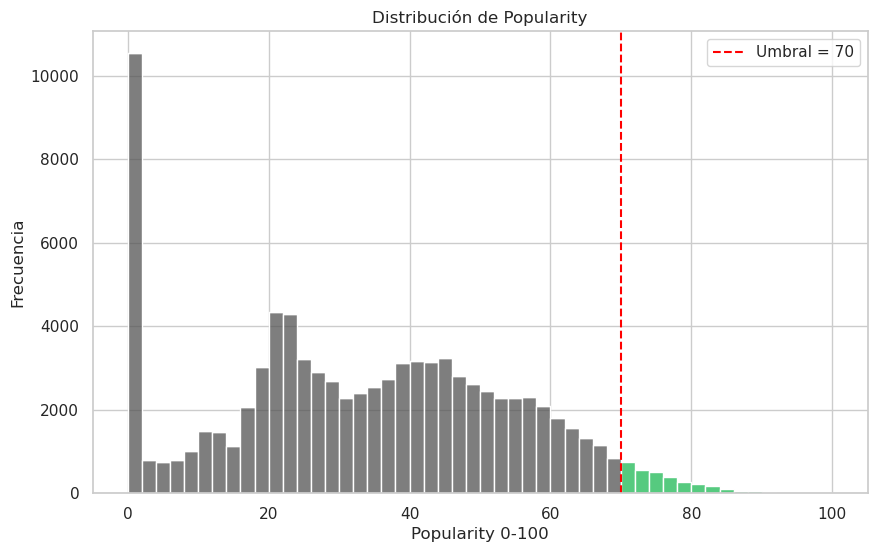

es_popular
No Popular    96.5
Popular        3.5
Name: proportion, dtype: float64


In [7]:
lim = 70
df['es_popular'] = df['popularity'] >= lim
df['es_popular'] = df['es_popular'].map({True: 'Popular', False: 'No Popular'})

# gráfica de barras
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='es_popular', hue='es_popular', 
                   palette={'Popular':'#1DB954', 'No Popular':'#535353'},
                   legend=False)
plt.title(f'Distribución de canciones: Populares vs No Populares | Corte: {lim}')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de canciones')

#cotas de barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.show()

# histograma
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='popularity', hue='es_popular', bins=50, 
             multiple='stack', palette={'No Popular':'#535353', 'Popular':'#1DB954'})
plt.axvline(lim, color='red', linestyle='--', label=f'Umbral = {lim}')
plt.title('Distribución de Popularity')
plt.xlabel('Popularity 0-100')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# porcentajes para ver el desbalance
print(df['es_popular'].value_counts(normalize=True).round(3) * 100)

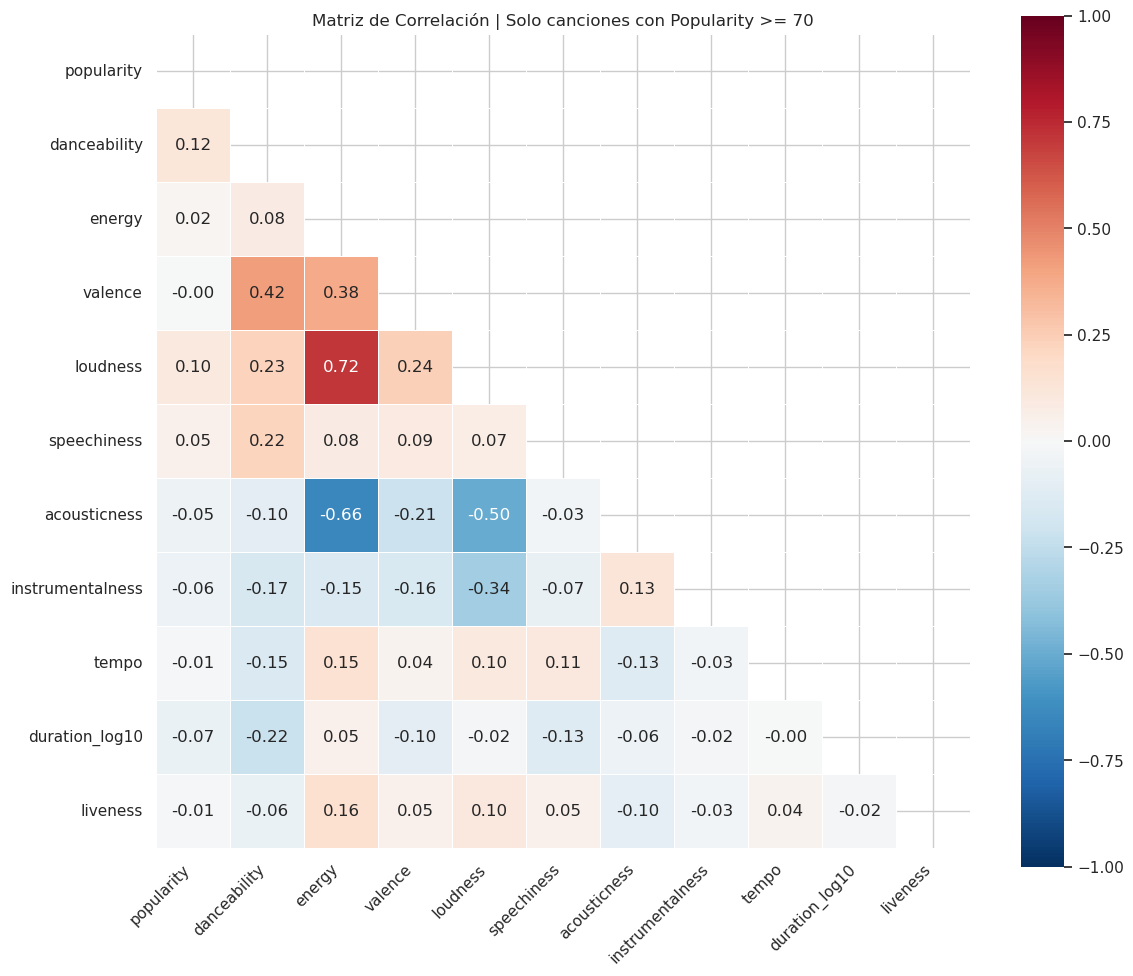


Top correlaciones con 'popularity' para tracks >= 70:
popularity          1.000000
danceability        0.124574
loudness            0.097317
speechiness         0.050825
energy              0.018374
valence            -0.001829
tempo              -0.013386
liveness           -0.013606
acousticness       -0.051939
instrumentalness   -0.060529
duration_log10     -0.066918
Name: popularity, dtype: float64


In [8]:
LIM = 70
df_populares = df[df['popularity'] >= LIM].copy()

# solo columnas numéricas que te interesan para el modelo
features_corr = ['popularity', 'danceability', 'energy', 'valence', 'loudness', 
                 'speechiness', 'acousticness', 'instrumentalness', 'tempo', 
                 'duration_log10', 'liveness']

# usa duration_ms
if 'duration_log10' not in df_populares.columns:
    df_populares['duration_log10'] = np.log10(df_populares['duration_ms'] + 1)

# calcula correlación solo del subset popular
corr_pop = df_populares[features_corr].corr()

# heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_pop, dtype=bool)) # Para mostrar solo mitad
sns.heatmap(corr_pop, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title(f'Matriz de Correlación | Solo canciones con Popularity >= {LIM}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Top correlaciones con popularity
print(f"\nTop correlaciones con 'popularity' para tracks >= {LIM}:")
print(corr_pop['popularity'].sort_values(ascending=False))

Canciones con popularity < 20: 23,034


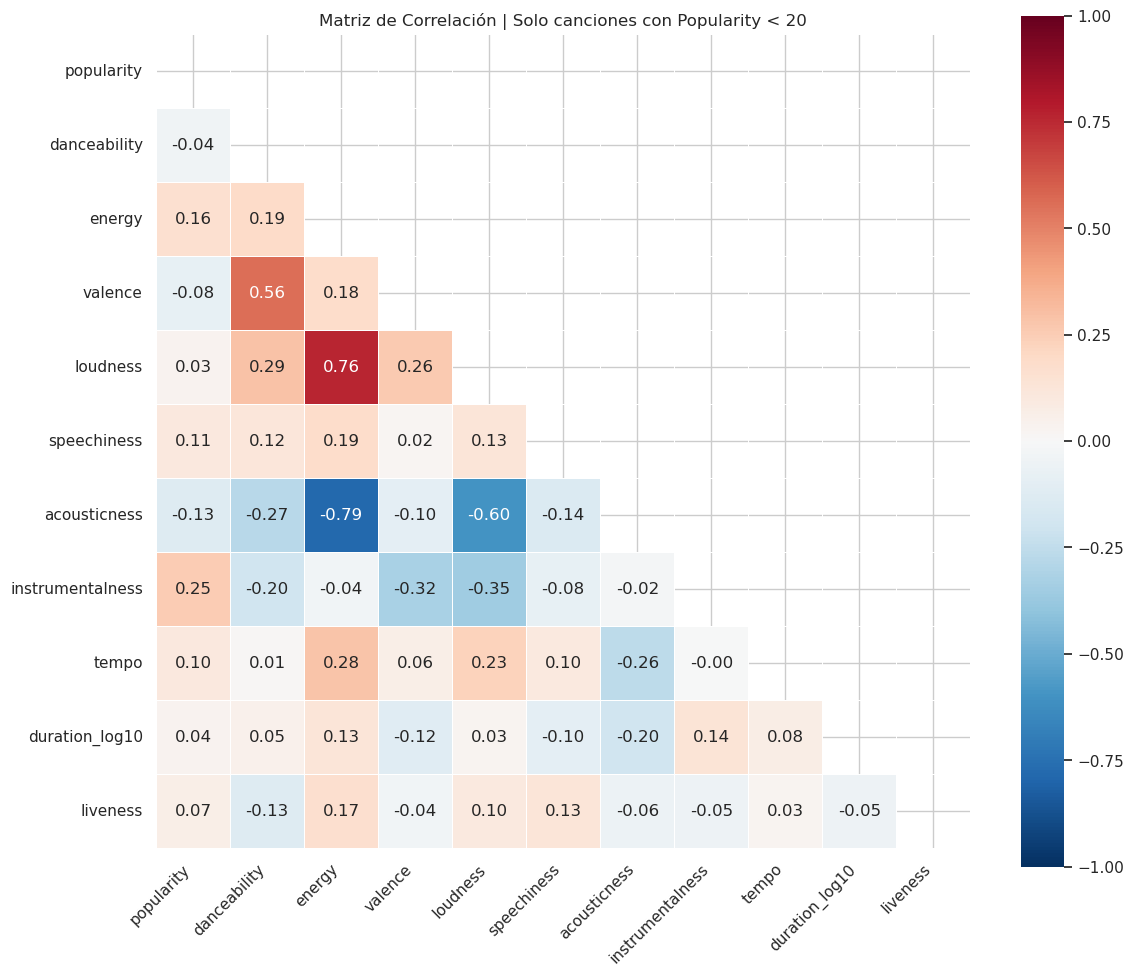


Top correlaciones con 'popularity' para tracks < 20:
popularity          1.000000
instrumentalness    0.254737
energy              0.157679
speechiness         0.109334
tempo               0.104396
liveness            0.066243
duration_log10      0.038574
loudness            0.033446
danceability       -0.040721
valence            -0.084985
acousticness       -0.132550
Name: popularity, dtype: float64


In [9]:
LIM_INF = 20
df_impopulares = df[df['popularity'] < LIM_INF].copy()
print(f"Canciones con popularity < {LIM_INF}: {len(df_impopulares):,}")

# features a correlacionar
features_corr = ['popularity', 'danceability', 'energy', 'valence', 'loudness', 
                 'speechiness', 'acousticness', 'instrumentalness', 'tempo', 
                 'duration_log10', 'liveness']

# crea duration_log10 si no existe
if 'duration_log10' not in df_impopulares.columns:
    df_impopulares['duration_log10'] = np.log10(df_impopulares['duration_ms'] + 1)

# calcula correlación solo del subset impopular
corr_impop = df_impopulares[features_corr].corr()

# heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_impop, dtype=bool))
sns.heatmap(corr_impop, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title(f'Matriz de Correlación | Solo canciones con Popularity < {LIM_INF}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# top correlaciones con popularity en las impopulares
print(f"\nTop correlaciones con 'popularity' para tracks < {LIM_INF}:")
print(corr_impop['popularity'].sort_values(ascending=False))

Analizando 3,126 canciones populares >=70


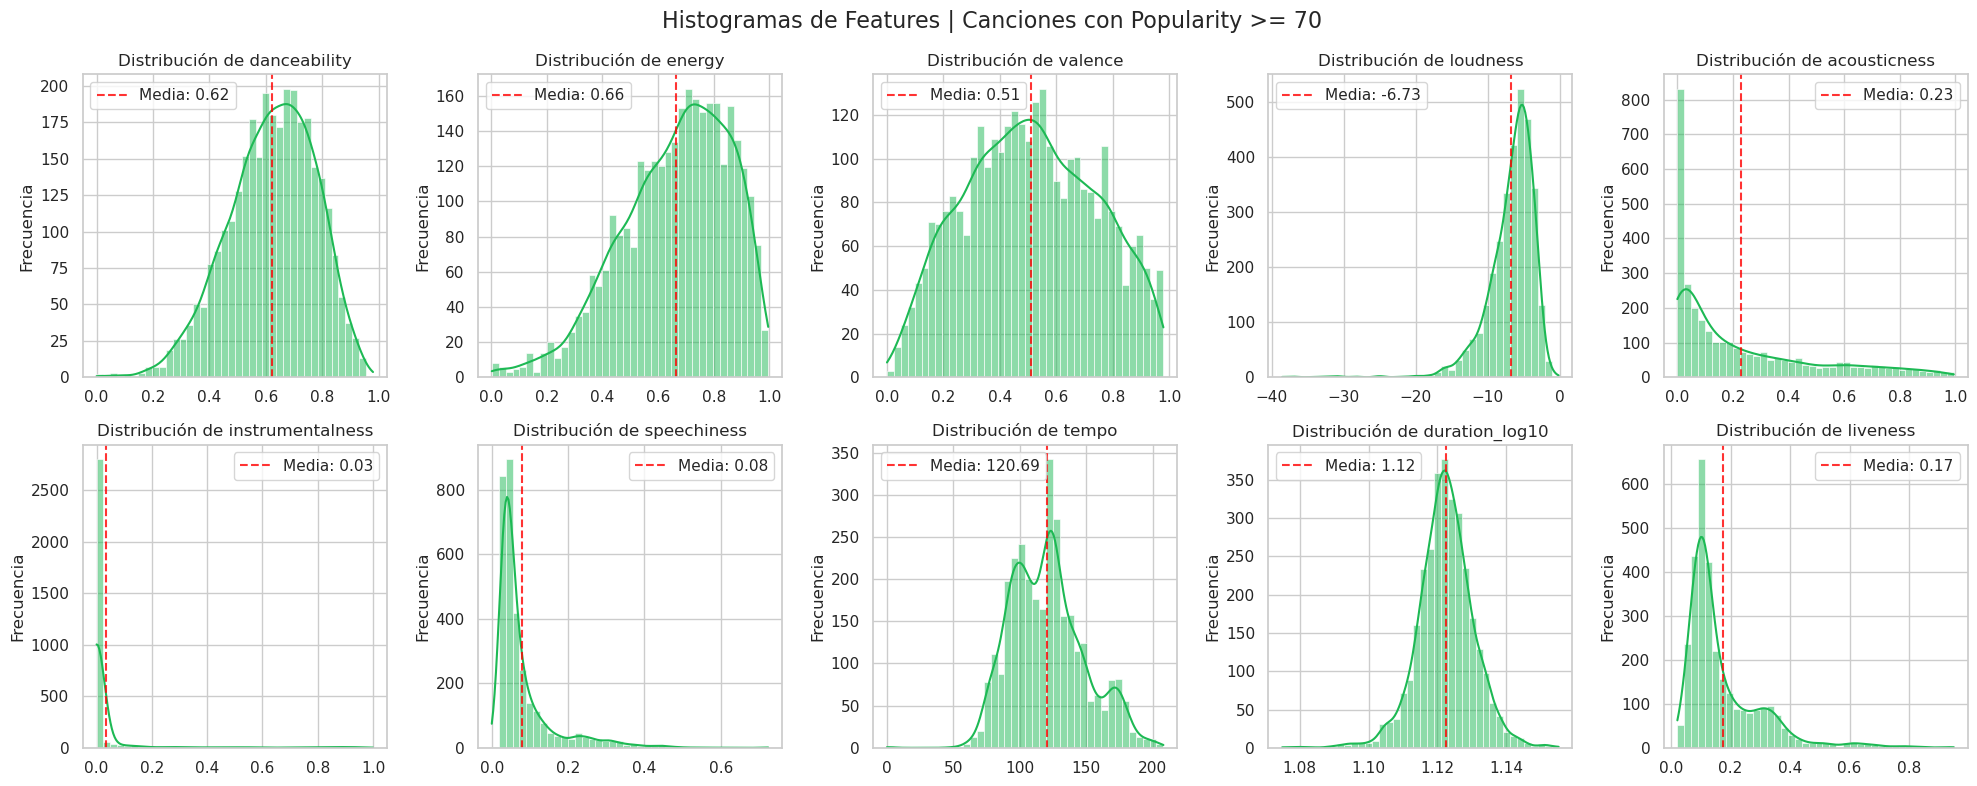

/tmp/ipykernel_5826/1636295824.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_genres.index, x=top_genres.values, palette='Greens_r')


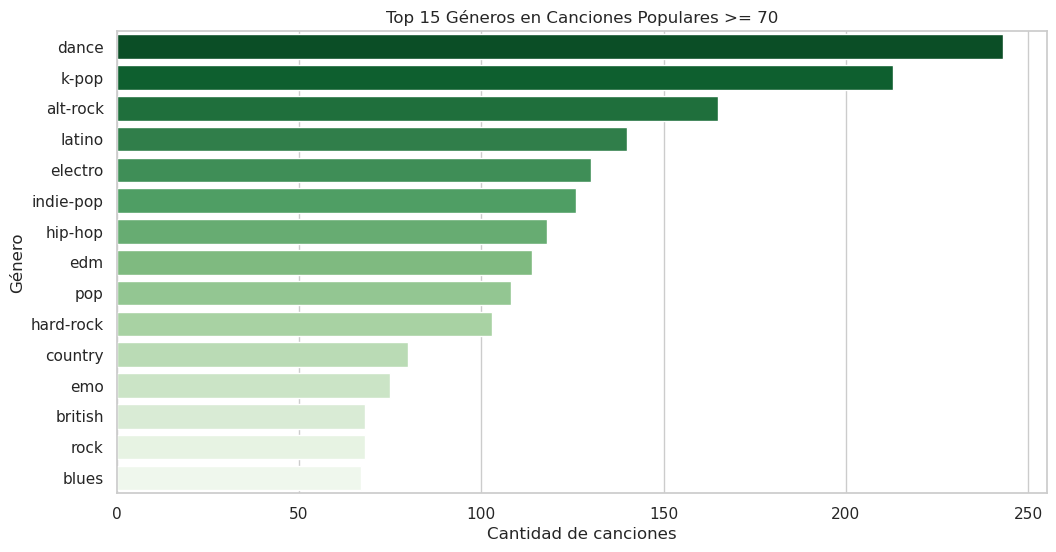

In [10]:
LIM = 70
df_pop = df[df['popularity'] >= LIM].copy()

# crea duration_log10 si no existe
if 'duration_log10' not in df_pop.columns:
    df_pop['duration_log10'] = np.log10(df_pop['duration_ms'] + 1)

print(f"Analizando {len(df_pop):,} canciones populares >={LIM}")

# features a graficar
features = ['danceability', 'energy', 'valence', 'loudness', 'acousticness', 
            'instrumentalness', 'speechiness', 'tempo', 'duration_log10', 'liveness']

# subplots: 2 filas x 5 columnas
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df_pop, x=col, bins=40, kde=True, ax=axes[i], color='#1DB954')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    
    # Línea de la media
    media = df_pop[col].mean()
    axes[i].axvline(media, color='red', linestyle='--', alpha=0.8, label=f'Media: {media:.2f}')
    axes[i].legend()

plt.suptitle(f'Histogramas de Features | Canciones con Popularity >= {LIM}', fontsize=16)
plt.tight_layout()
plt.show()

# top géneros en populares
if 'track_genre' in df.columns:
    plt.figure(figsize=(12, 6))
    top_genres = df_pop['track_genre'].value_counts().nlargest(15)
    sns.barplot(y=top_genres.index, x=top_genres.values, palette='Greens_r')
    plt.title(f'Top 15 Géneros en Canciones Populares >= {LIM}')
    plt.xlabel('Cantidad de canciones')
    plt.ylabel('Género')
    plt.show()

Analizando 23,034 canciones impopulares


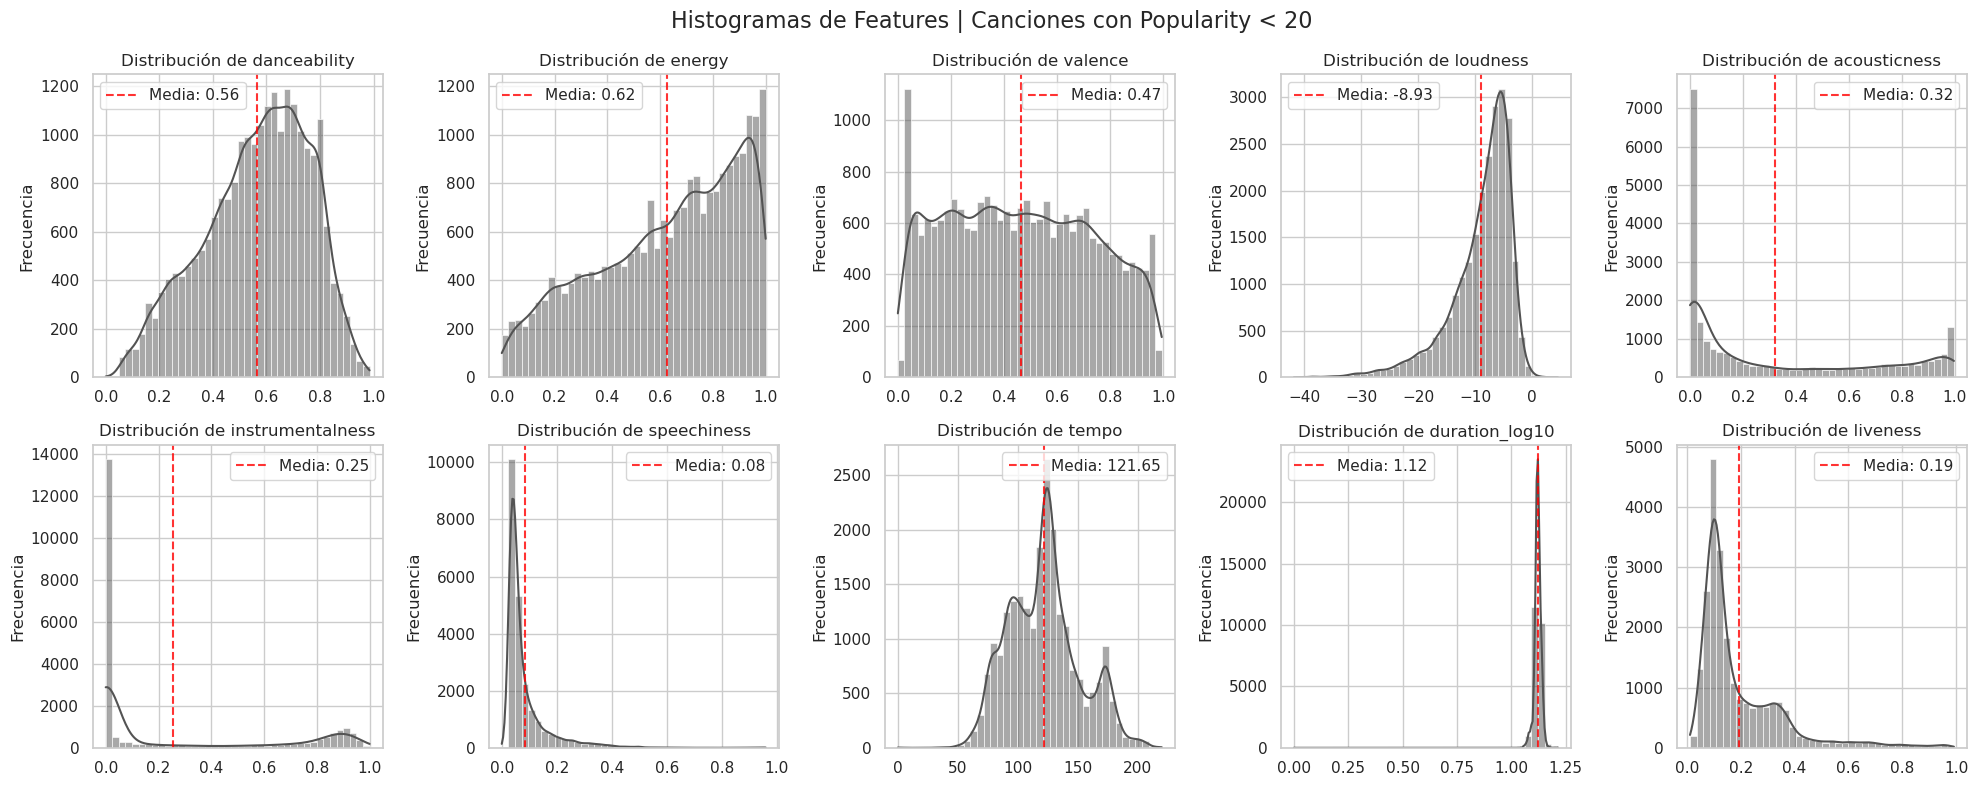

/tmp/ipykernel_5826/3726040005.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_genres.index, x=top_genres.values, palette='Greens_r')


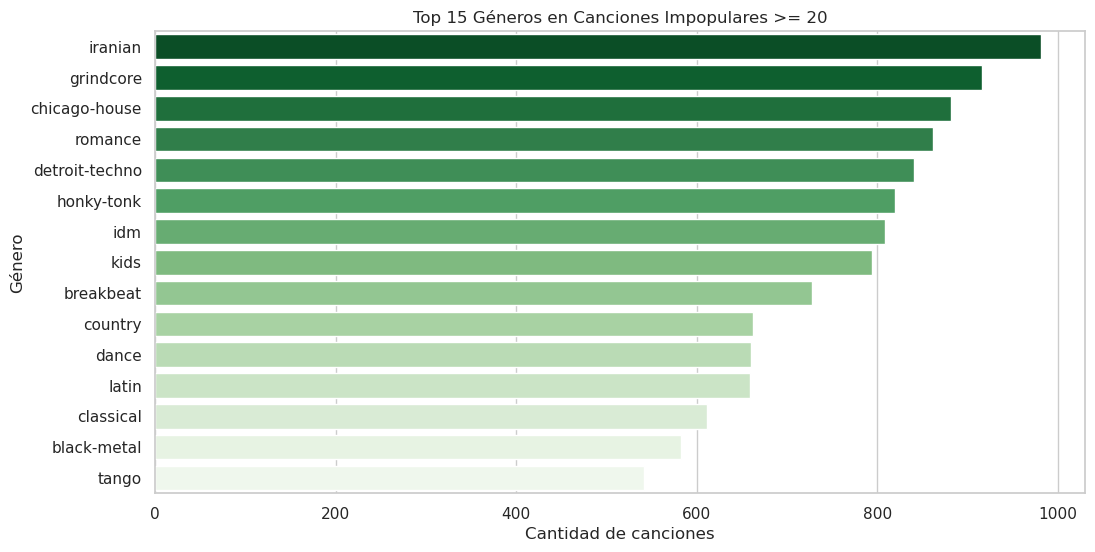

In [11]:
LIM_INF = 20
df_impop = df[df['popularity'] < LIM_INF].copy()

# crea duration_log si no existe
if 'duration_log10' not in df_impop.columns:
    df_impop['duration_log10'] = np.log10(df_impop['duration_ms'] + 1)

print(f"Analizando {len(df_impop):,} canciones impopulares")

# features a graficar
features = ['danceability', 'energy', 'valence', 'loudness', 'acousticness', 
            'instrumentalness', 'speechiness', 'tempo', 'duration_log10', 'liveness']

# subplots de 2 filas x 5 columnas
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df_impop, x=col, bins=40, kde=True, ax=axes[i], color='#535353')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    
    # Línea de la media
    media = df_impop[col].mean()
    axes[i].axvline(media, color='red', linestyle='--', alpha=0.8, label=f'Media: {media:.2f}')
    axes[i].legend()

plt.suptitle(f'Histogramas de Features | Canciones con Popularity < {LIM_INF}', fontsize=16)
plt.tight_layout()
plt.show()

if 'track_genre' in df.columns:
    plt.figure(figsize=(12, 6))
    top_genres = df_impop['track_genre'].value_counts().nlargest(15)
    sns.barplot(y=top_genres.index, x=top_genres.values, palette='Greens_r')
    plt.title(f'Top 15 Géneros en Canciones Impopulares >= {LIM_INF}')
    plt.xlabel('Cantidad de canciones')
    plt.ylabel('Género')
    plt.show()


In [12]:
LIM_POP = 70
LIM_IMPOP = 20

#  hits y fails
df['es_hit'] = df['popularity'] >= LIM_POP
df['es_fail'] = df['popularity'] < LIM_IMPOP

# agrupa por género y artista
resumen = df.groupby(['track_genre', 'artists']).agg(
    total_tracks=('popularity', 'count'),
    hits=('es_hit', 'sum'),
    fails=('es_fail', 'sum'),
    avg_popularity=('popularity', 'mean')
).reset_index()

# filtra solo artistas que tienen al menos 1 hit Y 1 fail
artistas_duales = resumen[(resumen['hits'] > 0) & (resumen['fails'] > 0)]

# ordena por los que más canciones tienen
artistas_duales = artistas_duales.sort_values('total_tracks', ascending=False)

print(f"Artistas con hits Y fails en el mismo género: {len(artistas_duales)}")
print(artistas_duales.head(20))

Artistas con hits Y fails en el mismo género: 436
       track_genre                artists  total_tracks  hits  fails  \
24289        piano            OneRepublic           124    16     48   
13601       garage         Arctic Monkeys           109    20      9   
20022         jazz          Nat King Cole           102     1    100   
25975   psych-rock         The Beach Boys           100     4     76   
13567         funk          Stevie Wonder            85     1     84   
27023   rockabilly             Brenda Lee            80     1     73   
29975         soul          The Jackson 5            77     1     76   
19657        j-pop            Norah Jones            73     3     68   
30659      swedish                   ABBA            71    14     31   
11927          emo           XXXTENTACION            67    20      1   
26817  rock-n-roll          Elvis Presley            62     6      1   
8898        disney           Randy Newman            58     1     17   
24465         

In [13]:
genero = 'latin' # Cambiar por 'dance', 'pop', etc

df_genero = df[df['track_genre'] == genero]
hits_artists = set(df_genero[df_genero['popularity'] >= LIM_POP]['artists'])
fails_artists = set(df_genero[df_genero['popularity'] < LIM_IMPOP]['artists'])

comunes = hits_artists & fails_artists
print(f"En {genero}: {len(comunes)} artistas tienen hits y fails")
print(f"Ejemplos: {list(comunes)[:10]}")

# ver caso concreto
if comunes:
    artista_ej = list(comunes)[0]
    print(f"\nCanciones de {artista_ej} en {genero}:")
    display(df_genero[df_genero['artists'] == artista_ej]
            [['track_name', 'album_name', 'popularity']]
           .sort_values('popularity', ascending=False))

En latin: 7 artistas tienen hits y fails
Ejemplos: ['J Balvin;Skrillex', 'Nelly Furtado', 'Bad Bunny;Drake', 'Luis Fonsi;Daddy Yankee;Justin Bieber', 'Nelly Furtado;Timbaland', 'Daddy Yankee', 'Luis Fonsi;Demi Lovato']

Canciones de J Balvin;Skrillex en latin:


,track_name,album_name,popularity
57110,In Da Getto,In Da Getto,75
57287,In Da Getto,JOSE,70
56951,In Da Getto,Regageton Para Niños,5
56974,In Da Getto,pov: it's 2021,0


In [14]:
LIM_POP = 70
LIM_IMPOP = 20

# hits y fails
df['es_hit'] = df['popularity'] >= LIM_POP
df['es_fail'] = df['popularity'] < LIM_IMPOP

# agrupa por género y artista
resumen = df.groupby(['track_genre', 'artists']).agg(
    total_tracks=('popularity', 'count'),
    hits=('es_hit', 'sum'),
    fails=('es_fail', 'sum'),
    avg_popularity=('popularity', 'mean')
).reset_index()

# calcula porcentajes
resumen['pct_hits'] = (resumen['hits'] / resumen['total_tracks'] * 100).round(1)
resumen['pct_fails'] = (resumen['fails'] / resumen['total_tracks'] * 100).round(1)
resumen['pct_mid'] = 100 - resumen['pct_hits'] - resumen['pct_fails'] # Lo que queda entre 20-69

# filtra solo artistas que tienen al menos 1 hit Y 1 fail
artistas_duales = resumen[(resumen['hits'] > 0) & (resumen['fails'] > 0)].copy()

# ordena por los que más canciones tienen
artistas_duales = artistas_duales.sort_values('total_tracks', ascending=False)

print(f"Artistas con hits Y fails en el mismo género: {len(artistas_duales)}")
print(artistas_duales[['track_genre', 'artists', 'total_tracks', 'hits', 'pct_hits', 'fails', 'pct_fails', 'avg_popularity']].head(20))

Artistas con hits Y fails en el mismo género: 436
       track_genre                artists  total_tracks  hits  pct_hits  \
24289        piano            OneRepublic           124    16      12.9   
13601       garage         Arctic Monkeys           109    20      18.3   
20022         jazz          Nat King Cole           102     1       1.0   
25975   psych-rock         The Beach Boys           100     4       4.0   
13567         funk          Stevie Wonder            85     1       1.2   
27023   rockabilly             Brenda Lee            80     1       1.2   
29975         soul          The Jackson 5            77     1       1.3   
19657        j-pop            Norah Jones            73     3       4.1   
30659      swedish                   ABBA            71    14      19.7   
11927          emo           XXXTENTACION            67    20      29.9   
26817  rock-n-roll          Elvis Presley            62     6       9.7   
8898        disney           Randy Newman         

mood
Neutra / Mixta          1488
Feliz / Eufórica         905
Iracunda / Agresiva      481
Triste / Melancólica     223
Tranquila / Relajada      29
Name: count, dtype: int64


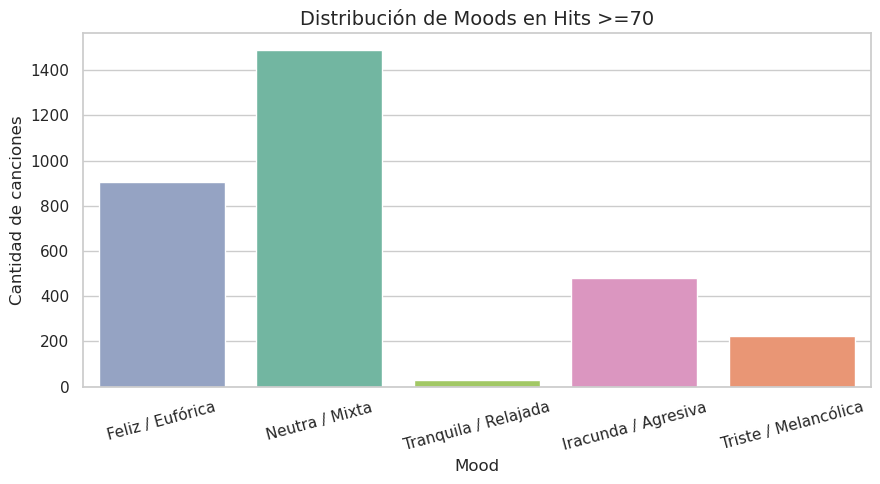

In [15]:
LIM_POP = 70

# Normaliza columnas por si acaso
df.columns = df.columns.str.lower()

# Filtra hits
df_hits = df[df['popularity'] >= LIM_POP].copy()

def clasificar_mood(row):
    v, e = row['valence'], row['energy']
    if v >= 0.6 and e >= 0.6: return 'Feliz / Eufórica'
    elif v >= 0.6 and e < 0.4: return 'Tranquila / Relajada'
    elif v < 0.4 and e >= 0.6: return 'Iracunda / Agresiva'
    elif v < 0.4 and e < 0.4: return 'Triste / Melancólica'
    else: return 'Neutra / Mixta'

df_hits['mood'] = df_hits.apply(clasificar_mood, axis=1)

# usando los hits y los estados de ánimo
print(df_hits['mood'].value_counts())# ordena los moods
orden_mood = ['Feliz / Eufórica', 'Neutra / Mixta', 'Tranquila / Relajada',
              'Iracunda / Agresiva', 'Triste / Melancólica']

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_hits,
    x='mood',
    hue='mood',        
    order=orden_mood,
    palette='Set2',
    legend=False       
)

plt.title('Distribución de Moods en Hits >=70', fontsize=14)
plt.xlabel('Mood')
plt.ylabel('Cantidad de canciones')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

mood
Neutra / Mixta          26187
Feliz / Eufórica        16632
Iracunda / Agresiva     13632
Triste / Melancólica     8784
Tranquila / Relajada     1472
Name: count, dtype: int64
mood
Neutra / Mixta          8875
Feliz / Eufórica        5772
Iracunda / Agresiva     5605
Triste / Melancólica    3760
Tranquila / Relajada    1080
Name: count, dtype: int64


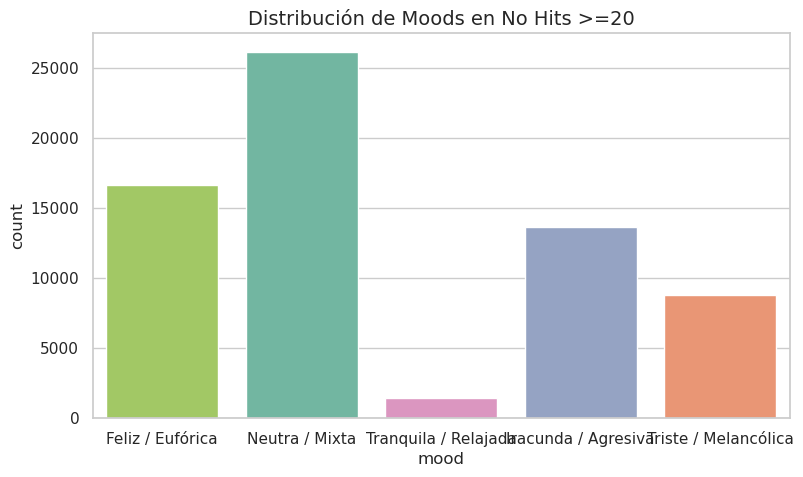

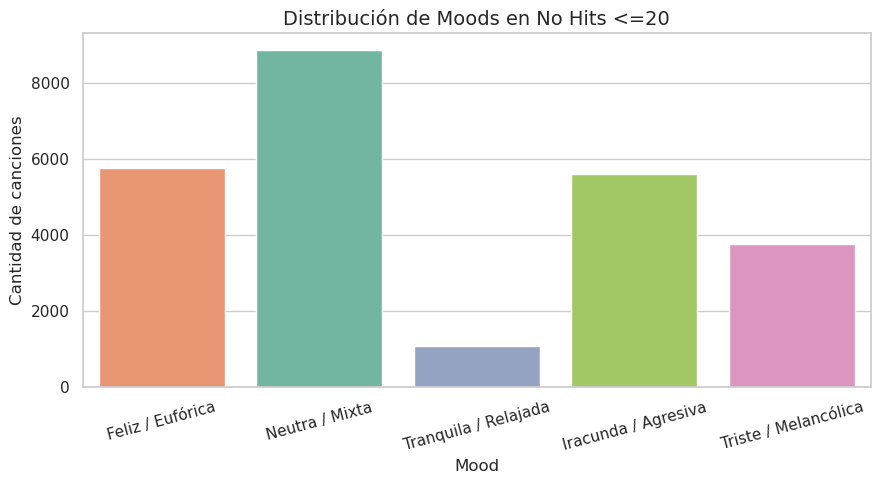

In [16]:
LIM_IMPOP = 20

df.columns = df.columns.str.lower()

# filtra los no hits
df_nohits = df[df['popularity'] >= LIM_IMPOP].copy()

def clasificar_mood(row):
    v, e = row['valence'], row['energy']
    if v >= 0.6 and e >= 0.6: return 'Feliz / Eufórica'
    elif v >= 0.6 and e < 0.4: return 'Tranquila / Relajada'
    elif v < 0.4 and e >= 0.6: return 'Iracunda / Agresiva'
    elif v < 0.4 and e < 0.4: return 'Triste / Melancólica'
    else: return 'Neutra / Mixta'


df_nohits['mood'] = df_nohits.apply(clasificar_mood, axis=1)

print(df_nohits['mood'].value_counts())

# ordena los moods
orden_mood = ['Feliz / Eufórica', 'Neutra / Mixta', 'Tranquila / Relajada',
              'Iracunda / Agresiva', 'Triste / Melancólica']

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_nohits,  # <- usa df_nohits
    x='mood',
    hue='mood',
    order=orden_mood,
    palette='Set2',
    legend=False
)

plt.title('Distribución de Moods en No Hits >=20', fontsize=14)  

#LIM_IMPOP = 20

df.columns = df.columns.str.lower()

# Filtra los no hits
df_nohits = df[df['popularity'] <= LIM_IMPOP].copy()

def clasificar_mood(row):
    v, e = row['valence'], row['energy']
    if v >= 0.6 and e >= 0.6: return 'Feliz / Eufórica'
    elif v >= 0.6 and e < 0.4: return 'Tranquila / Relajada'
    elif v < 0.4 and e >= 0.6: return 'Iracunda / Agresiva'
    elif v < 0.4 and e < 0.4: return 'Triste / Melancólica'
    else: return 'Neutra / Mixta'

# df_nohits aquí
df_nohits['mood'] = df_nohits.apply(clasificar_mood, axis=1)


print(df_nohits['mood'].value_counts())

# ordena los moods
orden_mood = ['Feliz / Eufórica', 'Neutra / Mixta', 'Tranquila / Relajada',
              'Iracunda / Agresiva', 'Triste / Melancólica']

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_nohits,  
    x='mood',
    hue='mood',
    order=orden_mood,
    palette='Set2',
    legend=False
)

plt.title('Distribución de Moods en No Hits <=20', fontsize=14) 
plt.xlabel('Mood')
plt.ylabel('Cantidad de canciones')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [17]:
# calcula correlaciones con popularity
corr = df.corr(numeric_only=True)['popularity'].abs().sort_values(ascending=False)

# deja las que tengan corr > 0.1
threshold = 0.1
features_importantes = corr[corr > threshold].index.tolist()
features_importantes.remove('popularity')  # quita la target

print("Features con corr > 0.1:", features_importantes)

# usa solo esas features
df_filtrado = df[features_importantes + ['popularity']]

Features con corr > 0.1: ['es_fail', 'es_hit', 'instrumentalness']


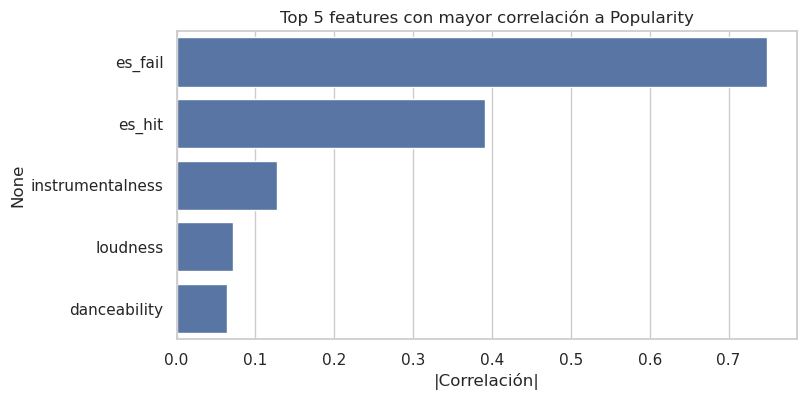

In [18]:
top_n = 5
top_corr = corr.head(top_n + 1).iloc[1:]  # quita popularity

plt.figure(figsize=(8, 4))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title(f'Top {top_n} features con mayor correlación a Popularity')
plt.xlabel('|Correlación|')
plt.show()

In [19]:
features_finalimp = ['instrumentalness', 'energy', 'speechiness', 'tempo']

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

features_finalimp = ['instrumentalness', 'energy', 'speechiness', 'tempo']

X = df[features_finalimp].fillna(0)
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

print("=== Regresión Lineal ===")
print(f"R²: {r2_score(y_test, y_pred_lin):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lin)):.2f}")
print("\nCoeficientes:")
for feat, coef in zip(features_finalimp, lin_reg.coef_):
    print(f"{feat}: {coef:.2f}")
print(f"Intercepto: {lin_reg.intercept_:.2f}")

=== Regresión Lineal ===
R²: 0.020
RMSE: 20.24

Coeficientes:
instrumentalness: -8.51
energy: -0.20
speechiness: -11.01
tempo: -0.00
Intercepto: 35.82


In [21]:
# Polinomio grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_poly_train, X_poly_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)
y_pred_poly = poly_reg.predict(X_poly_test)

print("\n=== Regresión Polinómica Grado 2 ===")
print(f"R²: {r2_score(y_test, y_pred_poly):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.2f}")


=== Regresión Polinómica Grado 2 ===
R²: 0.032
RMSE: 20.10


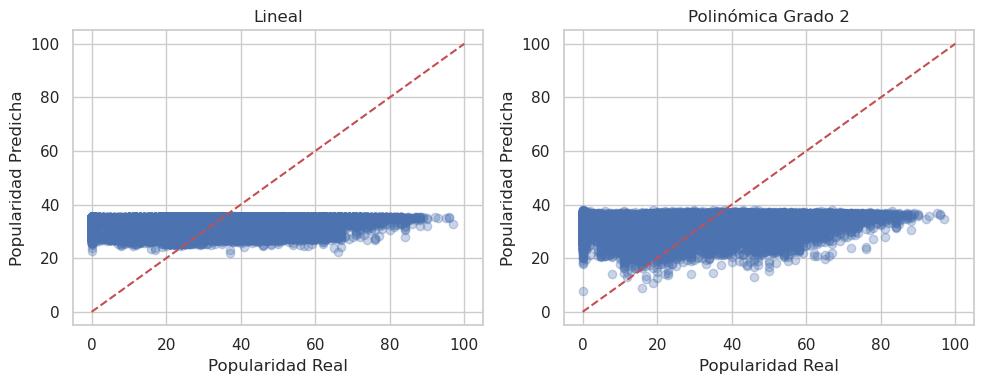

In [22]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Lineal')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_poly, alpha=0.3)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Polinómica Grado 2')

plt.tight_layout()
plt.show()

In [23]:
df_hits = df[df['popularity'] >= 70]
X_hits = df_hits[features_finalimp].fillna(0)
y_hits = df_hits['popularity']

=== Regresión Lineal - Solo Hits ===
R²: 0.005
RMSE: 5.10

Coeficientes:
instrumentalness: -1.59
energy: 0.41
speechiness: 2.89
tempo: -0.00
Intercepto: 75.59

=== Regresión Polinómica Grado 2 - Solo Hits ===
R²: 0.006
RMSE: 5.10


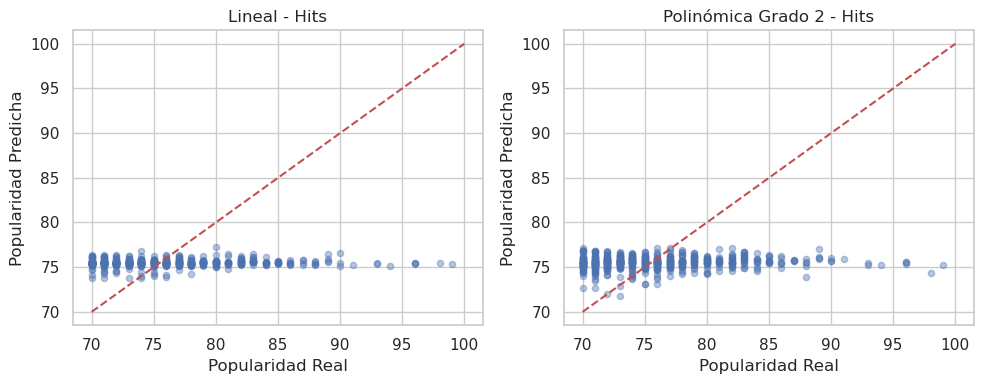

In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# filtra solo hits
features_finalimp = ['instrumentalness', 'energy', 'speechiness', 'tempo']
df_hits = df[df['popularity'] >= 70].copy()

X = df_hits[features_finalimp].fillna(0)
y = df_hits['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# regresión lineal por mínimos cuadrados
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

print("=== Regresión Lineal - Solo Hits ===")
print(f"R²: {r2_score(y_test, y_pred_lin):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lin)):.2f}")
print("\nCoeficientes:")
for feat, coef in zip(features_finalimp, lin_reg.coef_):
    print(f"{feat}: {coef:.2f}")
print(f"Intercepto: {lin_reg.intercept_:.2f}")

# regresión polinómica grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_poly_train, X_poly_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)
y_pred_poly = poly_reg.predict(X_poly_test)

print("\n=== Regresión Polinómica Grado 2 - Solo Hits ===")
print(f"R²: {r2_score(y_test, y_pred_poly):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.2f}")

# 4. Gráfica de ajuste
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lin, alpha=0.4, s=20)
plt.plot([70, 100], [70, 100], 'r--')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Lineal - Hits')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_poly, alpha=0.4, s=20)
plt.plot([70, 100], [70, 100], 'r--')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Polinómica Grado 2 - Hits')

plt.tight_layout()
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

df['es_hit'] = (df['popularity'] >= 70).astype(int)

features = ['danceability', 'energy', 'valence', 'acousticness',
            'instrumentalness', 'speechiness', 'tempo', 'loudness']

X = df[features].fillna(0)
y = df['es_hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

# Importancia de features
imp = pd.DataFrame({'feat': features, 'imp': clf.feature_importances_}).sort_values('imp', ascending=False)
print(imp)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17324
           1       0.00      0.00      0.00       625

    accuracy                           0.96     17949
   macro avg       0.48      0.50      0.49     17949
weighted avg       0.93      0.96      0.95     17949

AUC-ROC: 0.731
               feat       imp
4  instrumentalness  0.208953
7          loudness  0.175085
0      danceability  0.142691
3      acousticness  0.132247
1            energy  0.113809
6             tempo  0.089449
2           valence  0.074357
5       speechiness  0.063409


In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X[features])

# fit un modelo simple sobre las interacciones
clf_poly = LogisticRegression(max_iter=1000)
clf_poly.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters
df.groupby('cluster')['popularity'].agg(['mean', 'count'])

,mean,count
cluster,,
0,33.064105,29514
1,33.751598,22532
2,32.969060,25339
3,32.980981,12356


In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# crea la variable objetivo
df['es_hit'] = (df['popularity'] >= 70).astype(int)

features = ['danceability', 'energy', 'valence', 'acousticness',
            'instrumentalness', 'speechiness', 'tempo', 'loudness']

X = df[features].fillna(0)
y = df['es_hit']

# crea interacciones grado 2
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# divide después de crear X_poly
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, stratify=y, random_state=42
)

# entrena el modelo
clf_poly = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_poly.fit(X_train, y_train)

# evalúa
y_pred = clf_poly.predict(X_test)
y_proba = clf_poly.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       0.98      0.58      0.73     17324
           1       0.06      0.71      0.11       625

    accuracy                           0.59     17949
   macro avg       0.52      0.64      0.42     17949
weighted avg       0.95      0.59      0.71     17949

AUC-ROC: 0.714


/home/pauldirac13/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

df['es_hit'] = (df['popularity'] >= 70).astype(int)

features = ['danceability', 'energy', 'valence', 'acousticness',
            'instrumentalness', 'speechiness', 'tempo', 'loudness']

X = df[features].fillna(0)
y = df['es_hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

# Importancia de features
imp = pd.DataFrame({'feat': features, 'imp': clf.feature_importances_}).sort_values('imp', ascending=False)
print(imp)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17324
           1       0.00      0.00      0.00       625

    accuracy                           0.96     17949
   macro avg       0.48      0.50      0.49     17949
weighted avg       0.93      0.96      0.95     17949

AUC-ROC: 0.731
               feat       imp
4  instrumentalness  0.208953
7          loudness  0.175085
0      danceability  0.142691
3      acousticness  0.132247
1            energy  0.113809
6             tempo  0.089449
2           valence  0.074357
5       speechiness  0.063409


=== Regresión Ridge - Solo Hits ===
R²: 0.005
RMSE: 5.10

Coeficientes:
instrumentalness: -1.59
energy: 0.41
speechiness: 2.89
tempo: -0.00
Intercepto: 75.59

=== Regresión Polinómica Grado 2 - Solo Hits ===
R²: 0.006
RMSE: 5.10


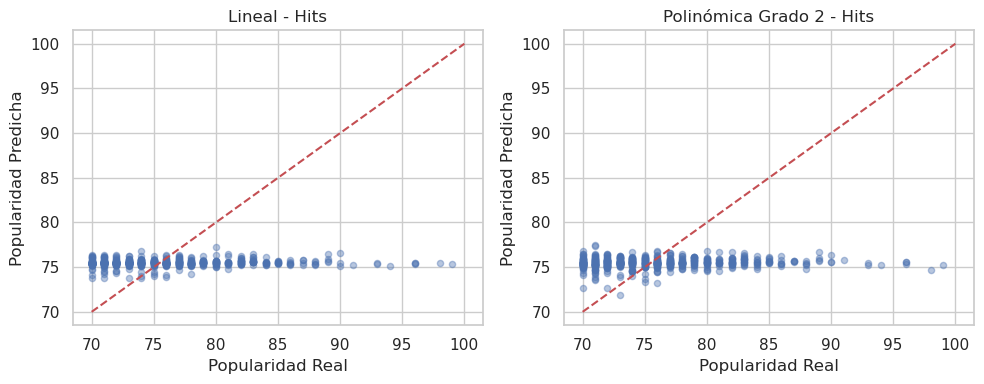

In [30]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# filtra solo hits
features_finalimp = ['instrumentalness', 'energy', 'speechiness', 'tempo']
df_hits = df[df['popularity'] >= 70].copy()

X = df_hits[features_finalimp].fillna(0)
y = df_hits['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# regresión lineal por mínimos cuadrados
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

print("=== Regresión Ridge - Solo Hits ===")
print(f"R²: {r2_score(y_test, y_pred_lin):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lin)):.2f}")
print("\nCoeficientes:")
for feat, coef in zip(features_finalimp, lin_reg.coef_):
    print(f"{feat}: {coef:.2f}")
print(f"Intercepto: {lin_reg.intercept_:.2f}")

# regresión polinómica grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_poly_train, X_poly_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_reg = Ridge()
poly_reg.fit(X_poly_train, y_train)
y_pred_poly = poly_reg.predict(X_poly_test)

print("\n=== Regresión Polinómica Grado 2 - Solo Hits ===")
print(f"R²: {r2_score(y_test, y_pred_poly):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.2f}")

# 4. Gráfica de ajuste
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lin, alpha=0.4, s=20)
plt.plot([70, 100], [70, 100], 'r--')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Lineal - Hits')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_poly, alpha=0.4, s=20)
plt.plot([70, 100], [70, 100], 'r--')
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Polinómica Grado 2 - Hits')

plt.tight_layout()
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

df['es_hit'] = (df['popularity'] >= 70).astype(int)

features = ['danceability', 'energy', 'valence', 'acousticness',
            'instrumentalness', 'speechiness', 'tempo', 'loudness']

X = df[features].fillna(0)
y = df['es_hit']

# Si quieres interacciones como antes
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, stratify=y, random_state=42
)

# MLE = logistic regression con solver que maximiza log-likelihood
clf = LogisticRegression(
    penalty=None, # sin regularización para MLE puro
    solver='lbfgs',
    max_iter=2000,
    class_weight='balanced'
)
clf.fit(X_train, y_train)

y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

# Máxima verosimilitud en test
log_lik = -log_loss(y_test, y_proba) * len(y_test)
print(f"Log-verosimilitud en test: {log_lik:.2f}")
print(f"Log-loss: {log_loss(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.59      0.73     17324
           1       0.06      0.71      0.11       625

    accuracy                           0.59     17949
   macro avg       0.52      0.65      0.42     17949
weighted avg       0.95      0.59      0.71     17949

AUC-ROC: 0.715
Log-verosimilitud en test: -11038.69
Log-loss: 0.6150


/home/pauldirac13/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Vemos que el modelo tuvo en su búsqueda el $71\%$ de los hits reales.
Por otro lado, si vemos la precisión, vemos cada cnción que marca como hit, sólo el $6.0\%$ lo son.
Así podemos ver que puede $71.5\%$ dar una puntuación más alta al hit que al no hit, lo que es válido con las características sonoras ()
\\

Como vemos, el logaritmo de máxima verosimilitud es malo, ya que su valor $-11038.69$, lo que nos dice que no es una buena comparación del modelo

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('clf', LogisticRegression(penalty=None, solver='lbfgs', max_iter=3000,class_weight='balanced'))
    ])

pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    penalty=None))])

In [45]:
y_proba = pipe.predict_proba(X_test)[:,1] #probabilidad de ser hit
y_pred =pipe.predict(X_test) #si es o no (1 0 0)

In [46]:
from sklearn.metrics import classification_report, roc_auc_score, log_loss

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba)}.3f")

#aplicamos máx verosimimilitud

log_lik = -log_loss(y_test, y_proba) * len(y_test)
print(f"Log-verosimilitud en test: {log_lik:.2f}")
print(f"Log-loss: {log_loss(y_test,y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.59      0.74     17324
           1       0.06      0.72      0.11       625

    accuracy                           0.60     17949
   macro avg       0.52      0.66      0.42     17949
weighted avg       0.95      0.60      0.72     17949

AUC-ROC: 0.7318054952666821.3f
Log-verosimilitud en test: -10534.10
Log-loss: 0.5869


In [47]:
hits_mask = y_test == 1
print(f"Recall en hits: {(y_pred[hits_mask] == 1).mean():.3f}")
print(f"Prob promedio que le da a los hits: {y_proba[hits_mask].mean():.3f}")

Recall en hits: 0.720
Prob promedio que le da a los hits: 0.587


In [36]:
hits_mask = y_test == 1
log_lik_hits = np.sum(np.log(y_proba[hits_mask] + 1e-12))
print(f"Log-verosimilitud en hits: {log_lik_hits:.2f}")
print(f"Probabilidad promedio predicha para hits: {y_proba[hits_mask].mean():.3f}")

Log-verosimilitud en hits: -383.78
Probabilidad promedio predicha para hits: 0.569


En este caso, usamos el algoritmo de máxima verosimilitud con la función log_loss para calcular la función de pérdida:

$$L_{log}(x,y)=-(ylog(p)+(1+y)log(1-p))$$

Como podemos observar, el modelo de máxima verosimilitud predice $56.9\%$ de los hits

In [38]:
import numpy as np

hits_mask = y_test == 1
log_lik_hits = np.sum(np.log(y_proba[hits_mask] + 1e-12))
print(f"Log-verosimilitud en hits: {log_lik_hits:.2f}")
print(f"Probabilidad promedio predicha para hits: {y_proba[hits_mask].mean():.3f}")


Log-verosimilitud en hits: -383.78
Probabilidad promedio predicha para hits: 0.569
